In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
%matplotlib inline
sns.set(color_codes=True)

# Scikit-learn tools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

# Other utilities
from math import sqrt
from numpy import mean, std

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv('/content/drive/My Drive/Mannings Data/Mannings Data with C and Yr.csv')

In [6]:
df

,COMID,nearest_x,nearest_y,NDVI,AreaSqKM,b0_sand,AI,CAT_STRM_DENS,Forest,Agriculture,...,sinuosity,StreamOrde,D50 (mm),mean_vel_v,max_depth,SLOPE,q_va,mannings n,C,Yr
0,4289887,-69.71557,46.70053,1495,4.1301,52.0,12802,0.33,76.79,6.21,...,1.27,4,0.233105,3.333,6.509757,0.003156,9814.643,0.087557,42.125928,1.090968
1,4289887,-69.71557,46.70053,1495,4.1301,52.0,12802,0.33,76.79,6.21,...,1.27,4,0.233105,2.147,4.275734,0.003156,3906.252,0.102705,33.482915,3.175871
2,4289887,-69.71557,46.70053,1495,4.1301,52.0,12802,0.33,76.79,6.21,...,1.27,4,0.233105,1.900,5.578986,0.003156,2682.989,0.138580,25.940152,5.650299
3,4289887,-69.71557,46.70053,1495,4.1301,52.0,12802,0.33,76.79,6.21,...,1.27,4,0.233105,0.791,3.874343,0.003156,2682.989,0.261039,12.959075,15.788431
4,4289887,-69.71557,46.70053,1495,4.1301,52.0,12802,0.33,76.79,6.21,...,1.27,4,0.233105,1.900,5.578986,0.003156,2682.989,0.138580,25.940152,5.650299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67428,24270972,-122.37330,48.32399,4100,0.7533,45.0,8807,2.59,0.00,29.99,...,1.10,6,2.763152,0.670,9.592593,0.000355,1740.000,0.189102,20.806859,8.586493
67429,24270972,-122.37330,48.32399,4100,0.7533,45.0,8807,2.59,0.00,29.99,...,1.10,6,2.763152,1.860,7.131783,0.000355,3420.000,0.055903,66.990559,0.074126
67430,24270972,-122.37330,48.32399,4100,0.7533,45.0,8807,2.59,0.00,29.99,...,1.10,6,2.763152,2.150,6.870229,0.000355,3870.000,0.047173,78.895562,0.024108
67431,24270972,-122.37330,48.32399,4100,0.7533,45.0,8807,2.59,0.00,29.99,...,1.10,6,2.763152,2.680,7.662835,0.000355,5380.000,0.040701,93.119316,0.003696


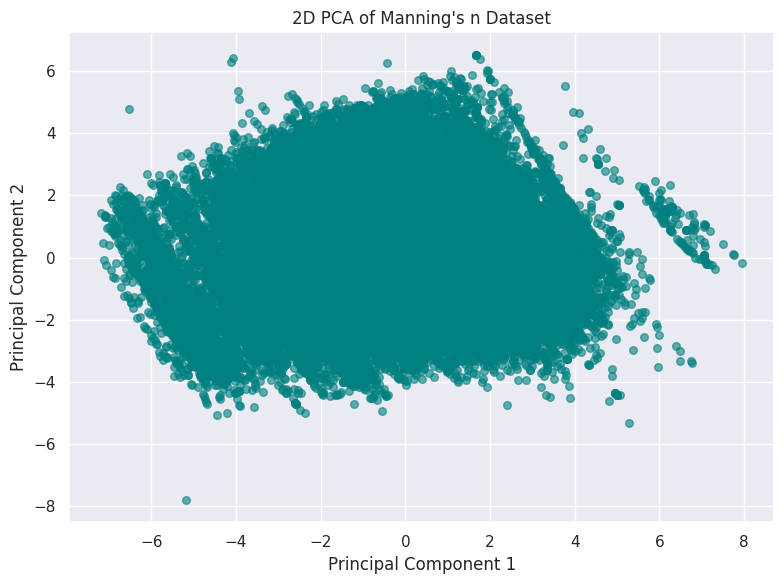

In [8]:
# --- Select Features (exclude non-numeric or identifiers) ---
features = df.drop(columns=['COMID', 'nearest_x', 'nearest_y'])  # adjust if needed

# --- Drop NaNs ---
features = features.dropna()

# --- Standardize ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# --- PCA to 2D ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Create a DataFrame for PCA results ---
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6, s=30, color='teal')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA of Manning\'s n Dataset')
plt.grid(True)
plt.tight_layout()
plt.show()

Few Insights:

🔹 1. General Data Spread / Variability
The data shows an elongated, dense core with a skew toward the right side of the plot (positive PC1).

This suggests the first principal component (PC1) captures the most variance and may be strongly influenced by one or more dominant features (e.g., area, streamflow, velocity, slope).

🔹 2. Correlation and Redundancy
The compact and continuous spread implies that many of your variables are correlated and possibly redundant. That’s why a 2D PCA can capture so much structure.

You could check the explained variance ratio to quantify how much variance PC1 and PC2 account for.

🔹 3. Outlier Behavior
Points that are far from the main cluster (e.g., bottom-left or far-right) may be outliers — possibly extreme values in variables like q_va, D50, or mean_vel_v.

These could represent unique or rare catchments (e.g., urban streams, flashy rivers, or very large rivers).

🔹 4. Potential for Clustering
Although no tight, well-separated clusters are visible, there is some shape structure and curvature in the cloud.

This suggests soft clustering or non-linear clustering (e.g., DBSCAN or UMAP) may still reveal more useful groupings.

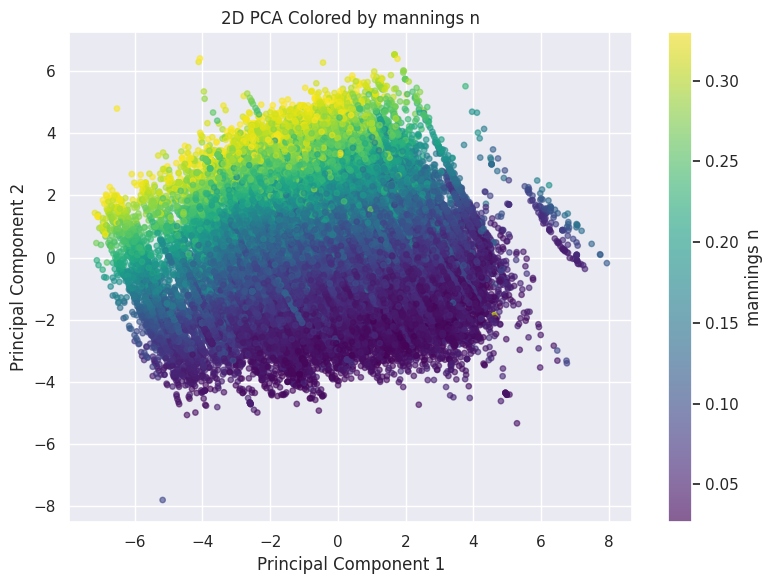

In [9]:
group_col = df.loc[features.index, 'mannings n']  # align index if features were cleaned

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=group_col, cmap='viridis', alpha=0.6, s=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Colored by mannings n')
plt.colorbar(scatter, label='mannings n')
plt.grid(True)
plt.tight_layout()
plt.show()

🔍 Key Observations from the Plot:

1. Gradient of Manning’s n across PC2:

- The color shifts smoothly from dark purple (low n) at the bottom to bright yellow (high n) at the top.

- This suggests Principal Component 2 (PC2) is strongly associated with Manning's n.

- Likely, PC2 is capturing variables related to surface roughness, such as vegetation (NDVI, Forest), slope, or stream morphology.

2. Clustered Patterns on the Right:

- The small “island” or cluster on the far right (high PC1, mid PC2) has consistently low Manning’s n.

- This might indicate a subset of river reaches (e.g., urban or engineered channels) with smooth beds or confined flows.

3. High Manning's n in Upper-Left Zone:

- Points in the top-left corner have very high n values, possibly representing natural channels in forested or mountainous regions with rough bed and high flow resistance.

💡 What You Can Conclude:
- Manning’s n is not random — it has a structured relationship with multiple input variables. PCA has helped compress this structure into a 2D space.

- PCA + Coloring reveals the latent gradient of physical roughness factors across the dataset.

- This also validates that you may predict Manning’s n (or classify it) using a low-dimensional representation or cluster membership.

In [10]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features.columns)
print(loadings.sort_values('PC2', ascending=False))

                    PC1       PC2
mannings n    -0.195953  0.479685
Yr            -0.202647  0.465102
b10_clay       0.361441  0.191280
b0_clay        0.358733  0.187163
Silt_101       0.270960  0.168583
SLOPE         -0.065813  0.127527
CAT_STRM_DENS  0.024427  0.105222
Agriculture    0.235240  0.060557
D50 (mm)       0.060017  0.023751
MEANELEVSMO    0.124189  0.016071
StreamOrde     0.169104 -0.006046
NDVI          -0.224970 -0.010970
Developed     -0.005357 -0.019747
sinuosity      0.073930 -0.024834
AreaSqKM      -0.012228 -0.037432
Forest        -0.191064 -0.038944
max_depth      0.108685 -0.049389
AI            -0.206982 -0.050716
q_va           0.118682 -0.124985
b0_sand       -0.349293 -0.210194
b10_sand      -0.349629 -0.211225
mean_vel_v     0.170630 -0.313699
C              0.212224 -0.458040


📊 Top Contributors to PC2 (influence on y-axis in PCA plot):

| Feature                           | PC2 Loading   | Interpretation                                                                                                 |
| --------------------------------- | ------------- | -------------------------------------------------------------------------------------------------------------- |
| `mannings n`                      | **0.48**      | Confirms PC2 is highly aligned with Manning’s n — validating your color-gradient observation.                  |
| `b10_clay`, `b0_clay`, `Silt_101` | **0.17–0.19** | Indicates **soil texture** (clay, silt) plays a strong role in PC2 — and hence in influencing **roughness**.   |
| `SLOPE`                           | **0.13**      | Positive influence; steeper terrains likely contribute to variability in n.                                    |
| `CAT_STRM_DENS`                   | **0.10**      | Denser stream networks may lead to higher friction/resistance.                                                 |


📉 Negative Contributors (Low/Inverse correlation with PC2)

| Feature               | PC2 Loading | Interpretation                                                            |
| --------------------- | ----------- | ------------------------------------------------------------------------- |
| `mean_vel_v`          | **−0.33**   | **Faster flows associated with lower Manning’s n**, as expected.          |
| `b10_sand`, `b0_sand` | **−0.21**   | **More sand → lower roughness** — smoother beds.                          |
| `q_va`                | **−0.12**   | Higher discharge correlates with lower n — typical in large rivers.       |

🔍 Key Insight Summary
- PC2 is a proxy for flow resistance, and is driven by:
- Positive: soil clay/silt content, slope, stream density → higher roughness.
- Negative: sand, velocity, discharge → smoother channels.
- This helps physically interpret the PCA axes, not just mathematically.

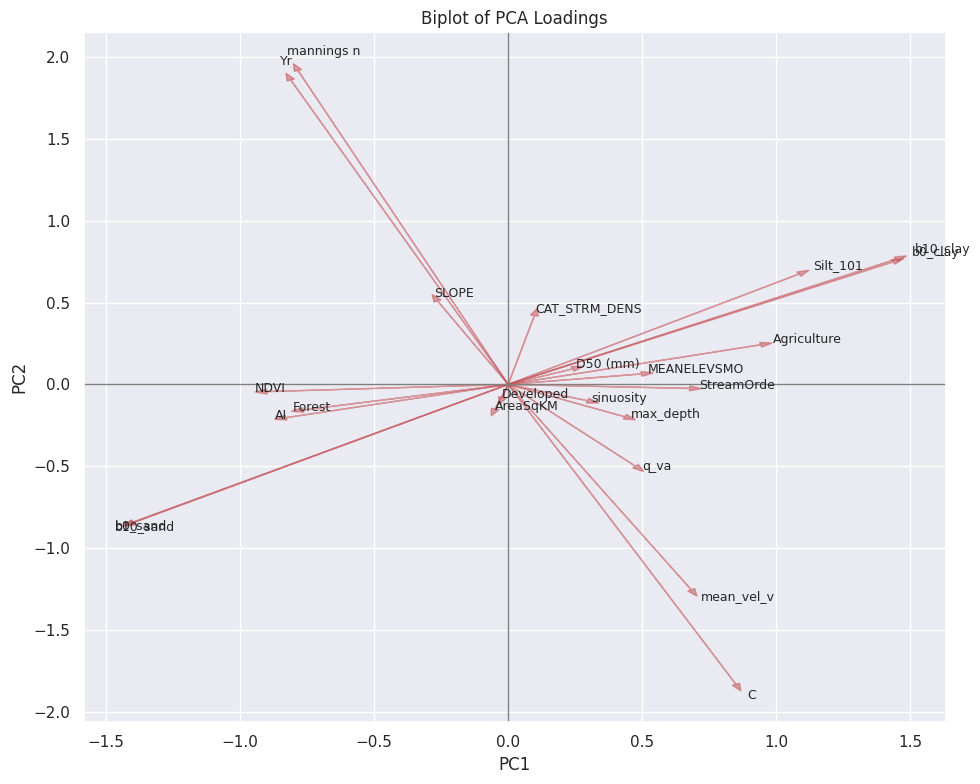

In [ ]:
# Plot biplot
plt.figure(figsize=(10, 8))
for i in range(loadings.shape[0]):
    plt.arrow(0, 0,
              loadings.iloc[i, 0] * 4,  # scale up for better visibility
              loadings.iloc[i, 1] * 4,
              color='r', alpha=0.5, head_width=0.03)
    plt.text(loadings.iloc[i, 0] * 4.2,
             loadings.iloc[i, 1] * 4.2,
             loadings.index[i], fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot of PCA Loadings')
plt.grid(True)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.tight_layout()
plt.show()

🔍 Key Interpretations:

- Right Side (Positive PC1):

-- Vectors like b10_clay, b0_clay, Silt_101, and Agriculture point strongly right → these features positively drive PC1.

-- Indicates PC1 captures soil texture and land use gradients.

- Upper Side (Positive PC2):

-- mannings n and SLOPE point strongly upward → they positively drive PC2.

-- PC2 is associated with temporal effects, terrain steepness, and roughness.

- Bottom Left (Negative PC1 & PC2):

-- b0_sand, b10_sand, mean_vel_v, and C pull downward/left → inverse relationship to clay-heavy, high-n regimes.

-- Indicates smoother, sand-dominated, fast-flowing systems.

- Opposing Arrows:

-- Arrows in opposite directions (e.g., mannings n vs. mean_vel_v) indicate negative correlation.